In [1]:
import kagglehub
import os

path = kagglehub.dataset_download("rohanrao/nifty50-stock-market-data")
print("Dataset Path:", path)

c:\Users\gurra\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 18.4M/18.4M [00:16<00:00, 1.17MB/s]

Extracting files...


Dataset Path: C:\Users\gurra\.cache\kagglehub\datasets\rohanrao\nifty50-stock-market-data\versions\15


In [2]:
import pandas as pd

df = pd.read_csv(os.path.join(path, "HDFCBANK.csv"))
df = df[['Date', 'Close']]

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

print(df.head())

        Date   Close
0 2000-01-03  170.00
1 2000-01-04  173.80
2 2000-01-05  166.95
3 2000-01-06  168.30
4 2000-01-07  168.35


In [3]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

scaler = MinMaxScaler()

data = scaler.fit_transform(df[['Close']])

In [4]:
def create_sequences(data, seq_length=30):
    X, y = [], []
    
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    
    return np.array(X), np.array(y)

X, y = create_sequences(data, 30)

print(X.shape, y.shape)

(5276, 30, 1) (5276, 1)


In [5]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

rnn_model = Sequential([
    SimpleRNN(50, activation='tanh', input_shape=(30,1)),
    Dense(1)
])

rnn_model.compile(
    optimizer='adam',
    loss='mse'
)

rnn_model.summary()

c:\Users\gurra\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
rnn_model.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_test, y_test)
)

Epoch 1/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0108 - val_loss: 0.0018
Epoch 2/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0014 - val_loss: 0.0014
Epoch 3/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0010 - val_loss: 9.2893e-04
Epoch 4/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 8.0823e-04 - val_loss: 0.0020
Epoch 5/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.4853e-04 - val_loss: 6.2024e-04
Epoch 6/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 5.6635e-04 - val_loss: 5.7161e-04
Epoch 7/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 5.0340e-04 - val_loss: 5.7404e-04
Epoch 8/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 5.0586e-04 - val_loss: 4.6727e-04
Epoch 9/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 4.4867e-04 - val_loss: 4.3890e-04
Epoch 10/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 4.0699e-04 - val_loss: 4.1308e-04


In [8]:
from tensorflow.keras.layers import LSTM

lstm_model = Sequential([
    LSTM(50, activation='tanh', input_shape=(30,1)),
    Dense(1)
])

lstm_model.compile(
    optimizer='adam',
    loss='mse'
)

In [9]:
lstm_model.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_test, y_test)
)

Epoch 1/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.0107 - val_loss: 0.0015
Epoch 2/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.0012 - val_loss: 0.0012
Epoch 3/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0011 - val_loss: 9.8656e-04
Epoch 4/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 9.3715e-04 - val_loss: 0.0014
Epoch 5/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 8.4332e-04 - val_loss: 7.6068e-04
Epoch 6/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 7.5488e-04 - val_loss: 7.2310e-04
Epoch 7/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 6.7258e-04 - val_loss: 8.4750e-04
Epoch 8/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 6.1114e-04 - val_loss: 6.1416e-04
Epoch 9/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5.5126e-04 - val_loss: 0.0026
Epoch 10/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5.7658e-04 - val_loss: 5.2949e-04


In [10]:
rnn_loss = rnn_model.evaluate(X_test, y_test)
lstm_loss = lstm_model.evaluate(X_test, y_test)

print("RNN Loss:", rnn_loss)
print("LSTM Loss:", lstm_loss)

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.1308e-04
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5.2949e-04
RNN Loss: 0.00041307631181553006
LSTM Loss: 0.000529494252987206


In [11]:
lstm_model.save("stock_model.keras")

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


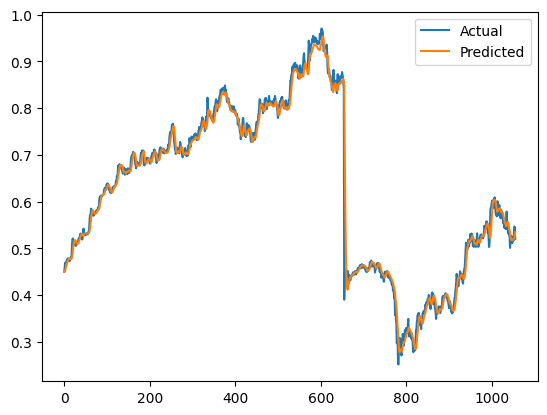

In [12]:
import matplotlib.pyplot as plt

plt.plot(y_test, label="Actual")
plt.plot(lstm_model.predict(X_test), label="Predicted")
plt.legend()
plt.show()

In [13]:
import pickle
pickle.dump(scaler, open("scaler.pkl", "wb"))